# Actividad 2
### Mateo Orozco Baldovino
### Especialidad en Estadistica Aplicada UTB
### Profesor: Fernando Salcedo

In [6]:
#!pip install wbgapi pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 15.0 MB/s eta 0:00:00


# Instalacion de las librerias necesarias



In [7]:
# Librerias necesarias

# Datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wbgapi as wb

# Modelos de tiempo
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

# Estadisticos
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.stattools import jarque_bera, durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')


# Analisis de los datos

# Visitantes de un sitio web

## *Contexto:*

Los datos fueron tomados de la base de datos de kaggle. Pueden ser encontrados en el siguiente link https://www.kaggle.com/datasets/bobnau/daily-website-visitors


Este archivo contiene datos diarios de tráfico web durante cinco años (del 14 de septiembre de 2014 al 19 de agosto de 2020) para un sitio académico de notas de pronósticos estadísticos. Incluye conteos de cargas de página, visitantes únicos, visitantes nuevos y recurrentes, con patrones de estacionalidad ligados al día de la semana y al calendario académico. Los visitantes se identifican por dirección IP y cookies, aunque puede haber subestimación en algunos casos.

In [14]:
# Importando la base de datos
df = pd.read_csv('/content/Visitantes.csv')
df.head()

,Row,Day,Day.Of.Week,Date,Page.Loads,Unique.Visits,First.Time.Visits,Returning.Visits
0,1,Sunday,1,9/14/2014,"2,146","1,582","1,430",152
1,2,Monday,2,9/15/2014,"3,621","2,528","2,297",231
2,3,Tuesday,3,9/16/2014,"3,698","2,630","2,352",278
3,4,Wednesday,4,9/17/2014,"3,667","2,614","2,327",287
4,5,Thursday,5,9/18/2014,"3,316","2,366","2,130",236


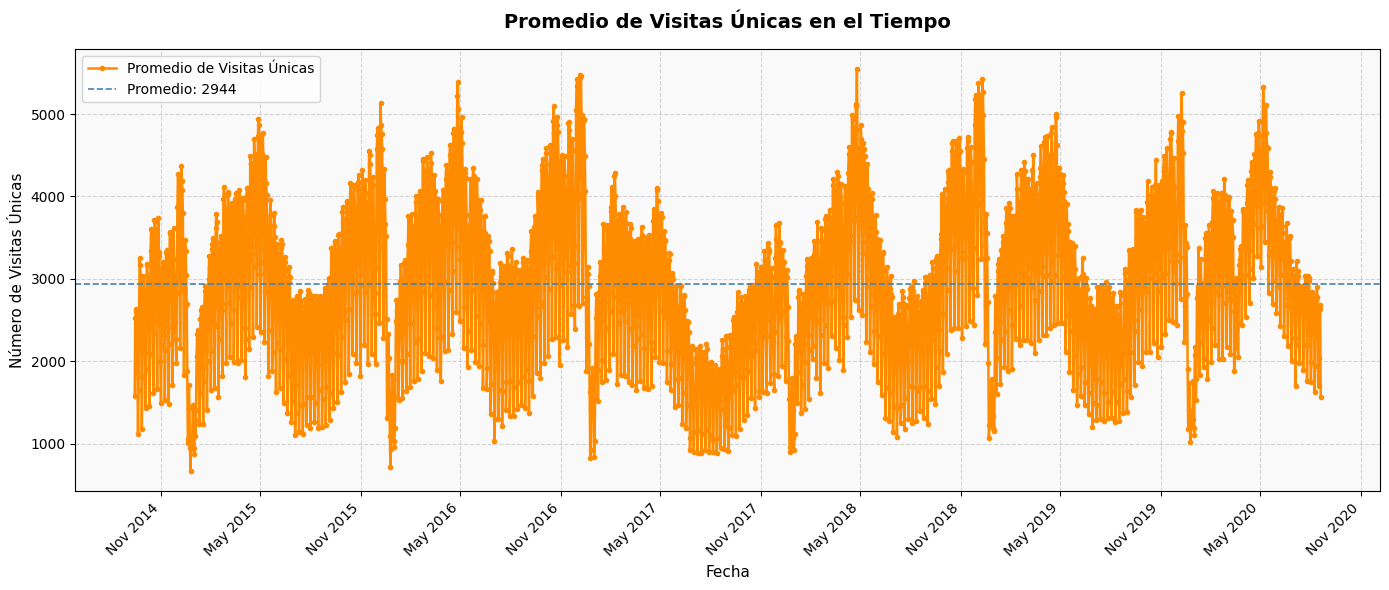

In [15]:
import matplotlib.dates as mdates # Importar mdates

df_copy = df.copy()

# Limpiar y convertir columnas numéricas a tipo numérico
for col in ['Page.Loads', 'Unique.Visits', 'First.Time.Visits', 'Returning.Visits']:
    df_copy[col] = df_copy[col].str.replace(',', '', regex=False).astype(int)

# Convertir la columna 'Date' a datetime
df_copy['Date'] = pd.to_datetime(df_copy['Date'])

# Agrupar por fecha por el promedio de visitas únicas
df_agrupado = df_copy.groupby('Date')['Unique.Visits'].mean().reset_index()
df_agrupado = df_agrupado.set_index('Date').sort_index()

# ── Graficado ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    df_agrupado.index,
    df_agrupado['Unique.Visits'],
    color='darkorange',
    linewidth=1.8,
    marker='o',
    markersize=3,        # Marcadores pequeños para no saturar
    label='Promedio de Visitas Únicas'
)

# Línea de promedio general
media = df_agrupado['Unique.Visits'].mean()
ax.axhline(media, color='steelblue', linestyle='--', linewidth=1.2, label=f'Promedio: {media:.0f}')

# ── Formato del eje X (fechas legibles) ───────────────────────────────────────
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))          # Cada 6 meses
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))           # Ej: Ene 2011
plt.xticks(rotation=45, ha='right')

# ── Etiquetas y estilo ─────────────────────────────────────────────────────────
ax.set_title('Promedio de Visitas Únicas en el Tiempo', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Fecha', fontsize=11)
ax.set_ylabel('Número de Visitas Únicas', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_facecolor('#f9f9f9')

plt.tight_layout()   # Evita que las etiquetas se corten
plt.savefig('unique_visits.png', dpi=150, bbox_inches='tight')  # Guardar figura
plt.show()
plt.close(fig)

### Análisis del Promedio de Visitas Únicas en el Tiempo (2014-2020)

La gráfica del promedio de visitas únicas desde septiembre de 2014 hasta agosto de 2020 muestra varias características:

1.  **Tendencia:** Inicialmente, se observa una tendencia general decreciente en el número de visitas únicas desde finales de 2014 hasta aproximadamente 2016-2017. Luego, la serie parece estabilizarse y, en ciertos períodos, muestra una ligera recuperación o una tendencia más volátil sin una dirección clara y sostenida.

2.  **Estacionalidad:** No se aprecia una estacionalidad tan marcada y regular como en otras series (como los pasajeros aéreos). Sin embargo, podría haber patrones estacionales o semanales/mensuales menos pronunciados, que requerirían un análisis más detallado (por ejemplo, descomposición estacional) para confirmarlos. Las fluctuaciones son bastante irregulares en comparación con una estacionalidad anual típica.

3.  **Variabilidad:** La serie presenta una variabilidad considerable a lo largo del tiempo, con picos y valles frecuentes. La magnitud de estas fluctuaciones parece ser relativamente constante en algunos períodos y más irregular en otros.

4.  **Eventos o Anomalías:** Podrían existir descensos abruptos o picos inusuales que no corresponden a un patrón regular, lo que podría indicar eventos externos (por ejemplo, cambios en el sitio web, campañas de marketing, eventos globales). Por ejemplo, hay una caída significativa en el promedio de visitas a principios de 2020, lo que podría coincidir con el inicio de la pandemia de COVID-19, aunque esto requeriría confirmación con datos externos.

**Conclusión:** La serie de visitas únicas es compleja, mostrando una mezcla de tendencias cambiantes y una variabilidad que no es claramente estacional a primera vista. Para un modelado preciso, sería crucial investigar las causas de las fluctuaciones observadas y considerar modelos que puedan manejar cambios en la tendencia y posibles anomalías.


# Verificar la estacionaridad de la serie original

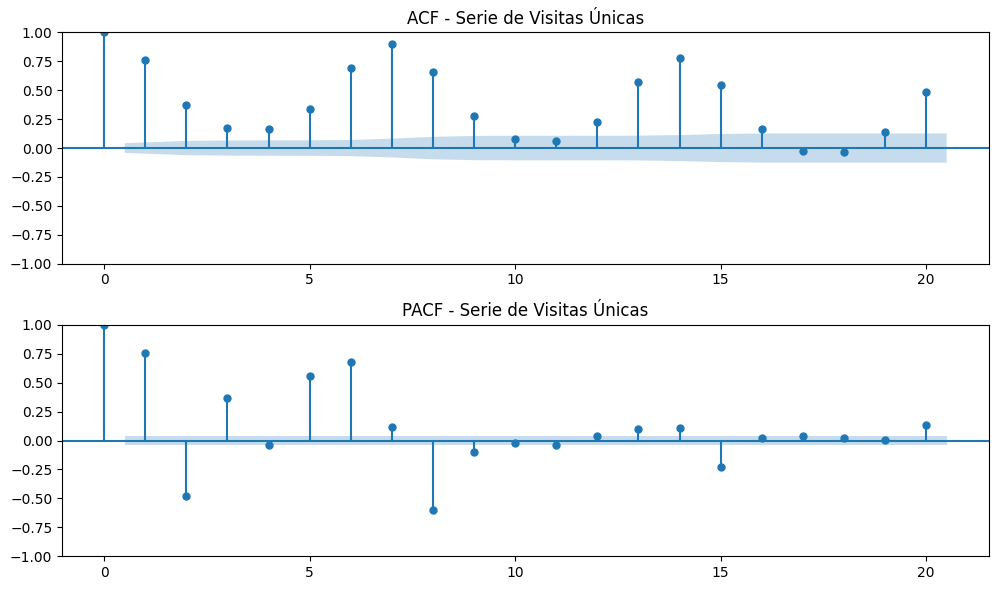

In [19]:
def graficar_autocorrelacion(data, title, maxlag=20):
    fig, axes = plt.subplots(2, 1, figsize=(10, 6))
    plot_acf(data, lags=maxlag, ax=axes[0], title=f'ACF - {title}')
    plot_pacf(data, lags=maxlag, ax=axes[1], title=f'PACF - {title}')
    plt.tight_layout()
    plt.show()

graficar_autocorrelacion(df_agrupado['Unique.Visits'], title="Serie de Visitas Únicas")

Las gráficas de la Función de Autocorrelación (ACF) y la Función de Autocorrelación Parcial (PACF) para la serie de Visitas Únicas nos proporcionan información clave sobre su estructura y estacionariedad:

*   **Función de Autocorrelación (ACF):** Se observa un decaimiento lento y gradual en los valores de la ACF. Esto es un indicador fuerte de la presencia de una **tendencia** en la serie temporal. El hecho de que la autocorrelación se mantenga alta por muchos rezagos sugiere que las observaciones pasadas tienen una influencia prolongada en las observaciones futuras. Este comportamiento confirma que la serie no es estacionaria.

*   **Función de Autocorrelación Parcial (PACF):** La PACF muestra varios picos significativos en los primeros rezagos, y luego tiende a caer rápidamente. La presencia de picos significativos en los primeros rezagos de la PACF, especialmente si no hay un corte abrupto después de unos pocos rezagos, también puede ser indicativo de no estacionariedad (una tendencia) y/o de componentes autorregresivos (AR). Si hubiera una tendencia pura, la PACF podría mostrar un solo pico significativo en el primer rezago, lo que no es el caso aquí, sugiriendo una combinación de efectos.

**Conclusión:**
Ambas gráficas, y especialmente el decaimiento lento de la ACF, refuerzan la idea de que la serie de Visitas Únicas **no es estacionaria**. Para un modelado de series de tiempo efectivo (por ejemplo, con modelos ARIMA), será necesario aplicar una diferenciación a la serie para remover la tendencia y lograr la estacionariedad. La forma de los picos en la PACF, una vez que la serie sea estacionaria, podría ayudar a identificar el orden de los componentes autorregresivos (p) de un modelo ARIMA.

# Pasajeros de Avion

## Contexto:

El dataset AirPassengers contiene el registro mensual del total de pasajeros internacionales de aerolíneas (en miles) desde enero de 1949 hasta diciembre de 1960, abarcando 144 observaciones a lo largo de 12 años. Fue recopilado por Box & Jenkins y publicado en su libro clásico "Time Series Analysis: Forecasting and Control" (1970), convirtiéndose en el benchmark más usado para modelos de series temporales. Los valores oscilan aproximadamente entre 104,000 y 622,000 pasajeros, mostrando dos patrones muy claros: una tendencia creciente sostenida año tras año (reflejo del auge de la aviación comercial en los 50s) y una estacionalidad anual marcada, con picos en los meses de verano (julio–agosto) y valles en invierno, lo que lo hace ideal para practicar tanto ARIMA como SARIMA, ya que combina los dos componentes que estos modelos buscan capturar.


In [28]:
# Cargar el dataset AirPassengers
data = sm.datasets.get_rdataset("AirPassengers", "datasets").data
data.head()

,time,value
0,1949.000000,112
1,1949.083333,118
2,1949.166667,132
3,1949.250000,129
4,1949.333333,121


In [29]:
# Crear una copia para evitar modificar el original
data_ap = data.copy()

In [30]:
# Generar un DatetimeIndex mensual comenzando en enero de 1949
start_date = '1949-01-01'
num_months = len(data_ap)
date_index = pd.date_range(start=start_date, periods=num_months, freq='MS')  # MS = Month Start

# Establecer el índice de fechas
data_ap.index = date_index

# Seleccionar la serie de pasajeros
serie_pasajeros = data_ap['value']

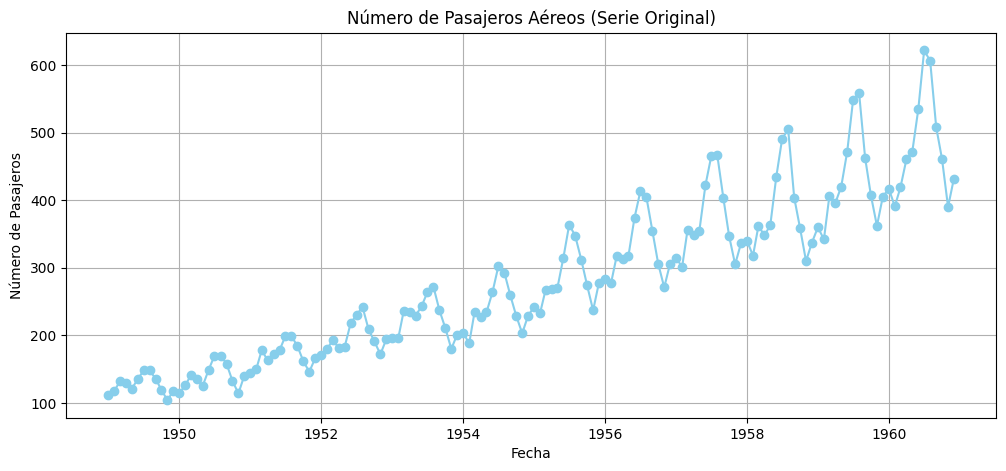

In [31]:
# ==============================
# 1. Gráfica de la serie original
# ==============================
plt.figure(figsize=(12, 5))
plt.plot(serie_pasajeros, marker='o', color='skyblue')
plt.title('Número de Pasajeros Aéreos (Serie Original)')
plt.xlabel('Fecha')
plt.ylabel('Número de Pasajeros')
plt.grid(True)
plt.show()

### Análisis de la Serie Original del Número de Pasajeros Aéreos

La gráfica del número de pasajeros aéreos desde 1949 hasta 1960 muestra claramente tres componentes principales de una serie de tiempo:

*   **Tendencia Ascendente:** Se observa una tendencia general al alza en el número de pasajeros a lo largo de todo el período. Esto indica un crecimiento constante en la industria de viajes aéreos durante estas décadas.
*   **Estacionalidad Pronunciada:** Existe un patrón estacional muy claro y regular. Cada año, hay picos consistentes, generalmente en los meses de verano (julio-agosto), y valles en los meses de invierno. Esto es típico de los viajes, que suelen aumentar en las temporadas de vacaciones.
*   **Variabilidad Creciente (Heterocedasticidad):** A medida que la serie avanza, la amplitud de las fluctuaciones estacionales parece aumentar. Es decir, la diferencia entre los picos y los valles estacionales se hace más grande con el tiempo, lo que sugiere que la variación estacional se vuelve más pronunciada a medida que el número total de pasajeros crece.

**Conclusión sobre la Serie Original:** La serie es **no estacionaria** debido a la presencia de una tendencia y una estacionalidad evidente. Un modelo adecuado para esta serie debería ser capaz de capturar tanto la tendencia a largo plazo como los patrones estacionales repetitivos, así como la posible heterocedasticidad (variabilidad creciente) en las fluctuaciones estacionales.

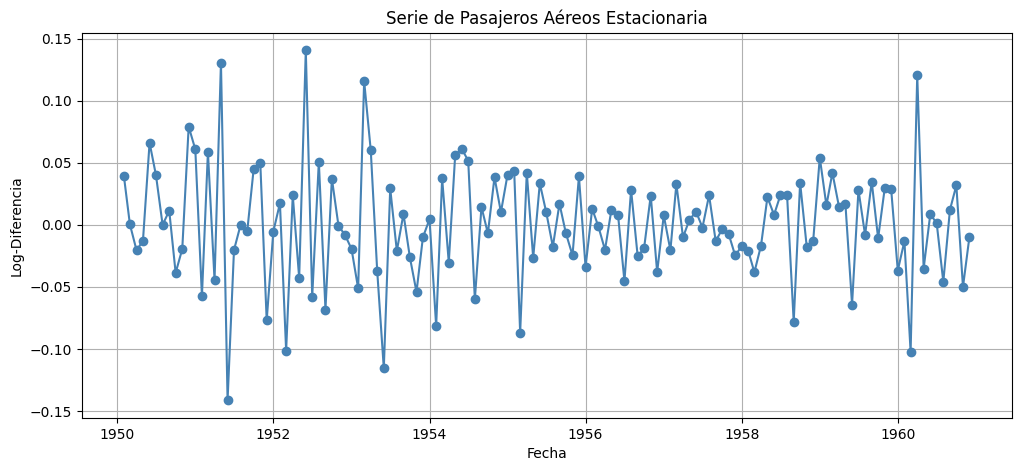

In [34]:
# =====================================
# 3. Gráfica de la serie estacionaria
# =====================================
plt.figure(figsize=(12, 5))
plt.plot(serie_estacionaria, marker='o', color='steelblue')
plt.title('Serie de Pasajeros Aéreos Estacionaria')
plt.xlabel('Fecha')
plt.ylabel('Log-Diferencia')
plt.grid(True)
plt.show()

### Análisis de la Serie de Pasajeros Aéreos Estacionaria y sus Gráficos ACF/PACF

Después de aplicar una transformación logarítmica para estabilizar la varianza, una diferenciación regular para eliminar la tendencia y una diferenciación estacional (con un rezago de 12 meses) para eliminar la estacionalidad, hemos obtenido la `serie_estacionaria`.

**1. Análisis de la Serie Estacionaria (Gráfico de la Serie Transformada):**

El gráfico de la serie de pasajeros aéreos estacionaria (Log-Diferencia) debería mostrar ahora:

*   **Media Constante:** La serie fluctúa alrededor de un valor medio constante, cercano a cero, sin una tendencia ascendente o descendente clara.
*   **Varianza Constante:** La amplitud de las fluctuaciones es relativamente constante a lo largo del tiempo, lo que indica que la transformación logarítmica y las diferenciaciones han logrado estabilizar la variabilidad.
*   **Sin Estacionalidad Evidente:** Los patrones estacionales pronunciados que se observaban en la serie original han sido eliminados, y las fluctuaciones parecen ser más aleatorias.

Estas características visuales sugieren que la serie es ahora **estacionaria**, lo cual es un requisito fundamental para aplicar modelos ARIMA.

**2. Análisis de los Gráficos de Autocorrelación (ACF) y Autocorrelación Parcial (PACF) de la Serie Estacionaria:**

Las gráficas de ACF y PACF de la serie estacionaria son cruciales para identificar los órdenes p, d, q (no estacionales) y P, D, Q, s (estacionales) de un modelo SARIMA.

*   **Función de Autocorrelación (ACF) de la Serie Estacionaria:**
    *   Deberíamos observar que la ACF **decae rápidamente a cero**. Esto es una fuerte confirmación visual de la estacionariedad.
    *   Picos significativos que se extienden más allá de los primeros rezagos o en rezagos estacionales (múltiplos de 12) podrían indicar la presencia de componentes de Media Móvil (MA) o Media Móvil Estacional (SMA).
    *   Si hay un pico significativo en el rezago 1 y luego decae, podría sugerir un componente MA(1). Si hay un pico significativo en el rezago estacional (por ejemplo, rezago 12) y luego decae, podría sugerir un componente SMA(1).

*   **Función de Autocorrelación Parcial (PACF) de la Serie Estacionaria:**
    *   Al igual que la ACF, la PACF también debería **decaer rápidamente a cero**, lo que refuerza la estacionariedad.
    *   Picos significativos en la PACF que 'cortan' bruscamente después de unos pocos rezagos o en rezagos estacionales (múltiplos de 12) podrían indicar la presencia de componentes Autorregresivos (AR) o Autorregresivos Estacionales (SAR).
    *   Si hay un pico significativo en el rezago 1 y luego 'corta' a cero, podría sugerir un componente AR(1). Si hay un pico significativo en el rezago estacional (por ejemplo, rezago 12) y luego 'corta', podría sugerir un componente SAR(1).

**Conclusión General de ACF/PACF de la Serie Estacionaria:**
El rápido decaimiento de ambas funciones, junto con la ausencia de patrones claros y persistentes más allá de unos pocos rezagos iniciales o estacionales, confirmaría que la serie es estacionaria. Los picos residuales significativos en estas gráficas nos darán pistas sobre los posibles órdenes (p, q, P, Q) del modelo SARIMA más adecuado para los datos.

# Verificar la estacionaridad de la serie original

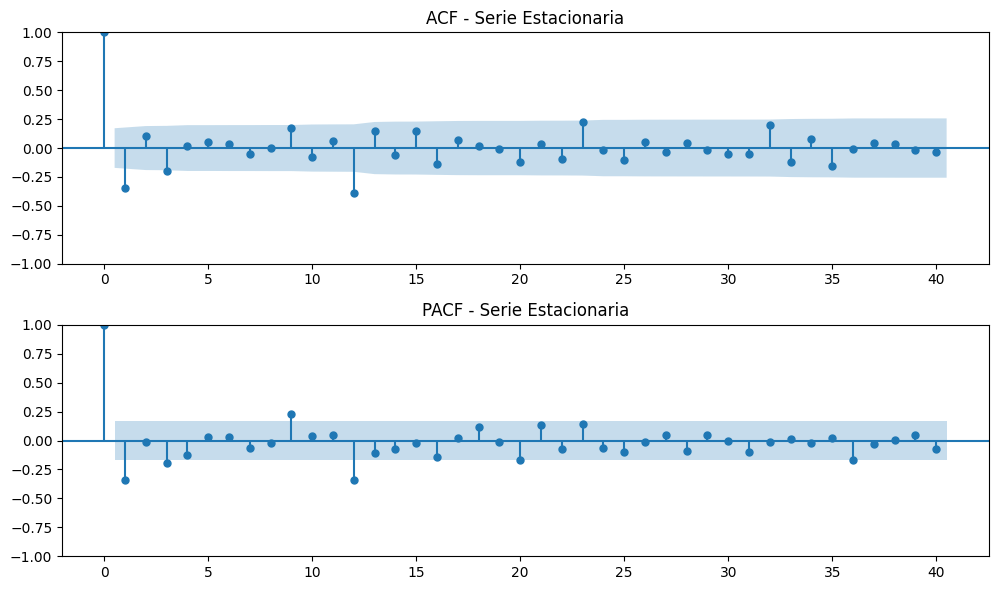

In [37]:
graficar_autocorrelacion(serie_estacionaria, title="Serie Estacionaria", maxlag=40)

Estacionariedad: La caída rápida de las correlaciones hacia cero confirma que la serie es estacionaria (no requiere más diferenciación).

Componente No Estacional: El pico significativo en el Lag 1 de ambos gráficos sugiere la presencia de términos AR(1) y MA(1) para capturar la dependencia inmediata.

Estacionalidad: Existe un pico prominente en el Lag 12 tanto en la ACF como en la PACF, lo que indica un patrón estacional mensual claro.

Ruido Blanco: La mayoría de los retardos intermedios se mantienen dentro del intervalo de confianza (bandas azules), lo que significa que no hay correlaciones significativas fuera de los puntos ya mencionados.

Sugerencia de Modelo: Los datos apuntan hacia un modelo SARIMA que integre componentes de corto plazo y términos estacionales en el periodo 12.

In [38]:
def test_autocorrelacion(datos, n_lags=20):
    # Ljung-Box (Prueba global)
    # Asegurarse de que los datos no contengan NaNs para Ljung-Box
    datos_limpios = datos.dropna()
    if not datos_limpios.empty:
        lb_test = acorr_ljungbox(datos_limpios, lags=n_lags, return_df=True)
        min_p_value = lb_test['lb_pvalue'].min()
        lb_stat = lb_test.loc[lb_test['lb_pvalue'] == min_p_value, 'lb_stat'].iloc[0]
    else:
        min_p_value = None
        lb_stat = None

    # Durbin-Watson (Autocorrelación de primer orden)
    # Durbin-Watson también necesita datos sin NaNs
    dw_stat = durbin_watson(datos_limpios)

    # Tabla de resultados
    tab_test = pd.DataFrame({
        'Test'        : ["Durbin-Watson", f"Ljung-Box (hasta lag {n_lags})"],
        'Estadístico' : [round(dw_stat, 4) if dw_stat is not None else None, round(lb_stat, 4) if lb_stat is not None else None],
        'P-valor'     : [None, round(min_p_value, 4) if min_p_value is not None else None]
    })

    # Conclusiones
    dw_conclu = (
        "Sin autocorrelación" if (dw_stat is not None and 1.5 < dw_stat < 2.5) else
        "Autocorrelación positiva" if (dw_stat is not None and dw_stat < 1.5) else
        "Autocorrelación negativa" if dw_stat is not None else "No aplica"
    )
    lb_conclu = "Sin autocorrelación" if (min_p_value is not None and min_p_value > 0.05) else "Autocorrelación detectada" if min_p_value is not None else "No aplica"
    tab_test['Conclusión'] = [dw_conclu, lb_conclu]

    print("=" * 80)
    print("PRUEBA DE LJUNG-BOX Y DURBIN-WATSON")
    print("=" * 80)
    print(tab_test)
    print("=" * 80)

# Llamar a la función con la serie_estacionaria
test_autocorrelacion(serie_estacionaria, n_lags=20)

PRUEBA DE LJUNG-BOX Y DURBIN-WATSON
                       Test  Estadístico  P-valor                 Conclusión
0             Durbin-Watson       2.6762      NaN   Autocorrelación negativa
1  Ljung-Box (hasta lag 20)      61.6452      0.0  Autocorrelación detectada


In [46]:
def test_estacionariedad(datos):
    # Augmented Dickey-Fuller
    adf_result = adfuller(datos)
    # KPSS
    kpss_result = kpss(datos, regression='c')

    # Tabla de resultados
    tab_test = pd.DataFrame({
        'Test'        : ["Prueba Augmented Dickey-Fuller (ADF)", "Prueba KPSS"],
        'Estadístico' : [round(adf_result[0],  4), round(kpss_result[0],  4)],
        'P-valor'     : [round(adf_result[1], 4), round(kpss_result[1], 4)],
        "Estacionario" : ["Sí" if adf_result[1] < 0.05 else "No", "No" if kpss_result[1] < 0.05 else "Sí"]
    })

    print("=" * 80)
    print("PRUEBA DE ESTACIONARIEDAD")
    print("=" * 80)
    print(tab_test)
    print("=" * 80)

test_estacionariedad(serie_estacionaria)

PRUEBA DE ESTACIONARIEDAD
                                   Test  Estadístico  P-valor Estacionario
0  Prueba Augmented Dickey-Fuller (ADF)      -4.4433   0.0002           Sí
1                           Prueba KPSS       0.0732   0.1000           Sí


In [48]:
m_arima110 = ARIMA(serie_estacionaria, order=(1, 1, 0)).fit()
print(m_arima110.summary())

# guardar modelos estimados
modelos = {}
modelos["ARIMA(1, 1, 0)"] = m_arima110

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  131
Model:                 ARIMA(1, 1, 0)   Log Likelihood                 190.343
Date:                Sat, 11 Apr 2026   AIC                           -376.686
Time:                        14:47:59   BIC                           -370.951
Sample:                    02-01-1950   HQIC                          -374.356
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6641      0.062    -10.748      0.000      -0.785      -0.543
sigma2         0.0031      0.000      9.483      0.000       0.002       0.004
Ljung-Box (L1) (Q):                   5.04   Jarque-

In [49]:
# ARIMA(0, 1, 1)
m_arima011 = ARIMA(serie_estacionaria, order = (0, 0, 1)).fit()
print(m_arima011.summary())

# guardar
modelos["ARIMA(0, 1, 1)"] = m_arima011

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  131
Model:                 ARIMA(0, 0, 1)   Log Likelihood                 226.995
Date:                Sat, 11 Apr 2026   AIC                           -447.991
Time:                        14:48:07   BIC                           -439.365
Sample:                    02-01-1950   HQIC                          -444.486
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003      0.002      0.108      0.914      -0.004       0.005
ma.L1         -0.3872      0.070     -5.529      0.000      -0.524      -0.250
sigma2         0.0018      0.000      9.018      0.0

In [50]:
# ARIMA(1, 1, 1)
m_arima111 = ARIMA(serie_estacionaria, order = (1, 0, 1)).fit()
print(m_arima111.summary())

# guardar
modelos["ARIMA(1, 1, 1)"] = m_arima111

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  131
Model:                 ARIMA(1, 0, 1)   Log Likelihood                 227.133
Date:                Sat, 11 Apr 2026   AIC                           -446.266
Time:                        14:48:45   BIC                           -434.765
Sample:                    02-01-1950   HQIC                          -441.593
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003      0.002      0.121      0.904      -0.004       0.004
ar.L1          0.1449      0.187      0.773      0.439      -0.222       0.512
ma.L1         -0.5190      0.163     -3.183      0.0

In [52]:
# Auto-ARIMA encuentra los parámetros óptimos automáticamente
m_autoARIMA = auto_arima(serie_estacionaria,
                         seasonal=False,      # No seasonal
                         stepwise=True,       # Búsqueda por pasos
                         trace=True,          # Mostrar progreso
                         error_action='ignore',
                         suppress_warnings=True,
                         start_p=0, start_q=0, max_p=5, max_q=5, d=0)

print("Auto-ARIMA")
print(m_autoARIMA.summary())
print(f'Parámetros óptimos: ARIMA{m_autoARIMA.order}')

# Guardar el modelo ARIMA con los parámetros óptimos encontrados por auto_arima
modelos["auto-ARIMA"] = ARIMA(serie_estacionaria, order=m_autoARIMA.order, trend="c").fit()

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-434.830, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-449.013, Time=0.08 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-449.978, Time=0.27 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-448.251, Time=0.67 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=-448.084, Time=0.66 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-446.719, Time=0.63 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-447.991, Time=0.25 sec

Best model:  ARIMA(0,0,1)(0,0,0)[0]          
Total fit time: 2.610 seconds
Auto-ARIMA
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  131
Model:               SARIMAX(0, 0, 1)   Log Likelihood                 226.989
Date:                Sat, 11 Apr 2026   AIC                           -449.978
Time:                        14:49:56   BIC                           -444.228
Sample:     

In [53]:
import pandas as pd
import numpy as np

def comparar_modelos_arima(modelos: dict) -> tuple[pd.DataFrame, str]:
    data = []
    for nombre_modelo, m in modelos.items():
        # Calculate AICc
        k = m.df_model # number of parameters
        n = m.nobs     # number of observations
        # Handle cases where n - k - 1 <= 0 to avoid division by zero or negative
        aicc = m.aic + (2 * k * (k + 1)) / (n - k - 1) if (n - k - 1) > 0 else np.inf

        # Calculate MSE and MAE from residuals
        mse = (m.resid**2).mean()
        mae = np.abs(m.resid).mean()

        data.append({
            "Modelo": nombre_modelo,
            "AIC": m.aic,
            "AICc": aicc,
            "BIC": m.bic,
            "Log-Lik": m.llf,
            "MSE": mse,
            "RMSE": mse**0.5,
            "MAE": mae,
            "Params": m.df_model,
            "Obs": m.nobs,
        })

    df_modelos = (
        pd.DataFrame(data)
        .sort_values("AICc")
        .assign(Ranking=lambda df: range(1, len(df) + 1))
        .set_index("Ranking")
    )

    mejor_nombre_modelo = df_modelos.iloc[0]["Modelo"]
    mejor_aicc = df_modelos.iloc[0]["AICc"]

    print("=" * 100)
    print("COMPARACIÓN DE MODELOS ARIMA")
    print("=" * 100)
    print(df_modelos.to_string())
    print("-" * 100)
    print(f"Mejor modelo (menor AICc): {mejor_nombre_modelo}  →  AICc: {mejor_aicc}")
    print("=" * 100)

    return df_modelos, mejor_nombre_modelo

# Call the function and get the best model name
df_comparacion, mejor_modelo_nombre = comparar_modelos_arima(modelos)

# Then assign the actual best model object based on the comparison
mejor_modelo = modelos[mejor_modelo_nombre]

COMPARACIÓN DE MODELOS ARIMA
                 Modelo         AIC        AICc         BIC     Log-Lik       MSE      RMSE       MAE  Params  Obs
Ranking                                                                                                           
1        ARIMA(0, 1, 1) -447.990781 -447.801804 -439.365189  226.995390  0.001829  0.042770  0.032542       3  131
2            auto-ARIMA -447.990781 -447.801804 -439.365189  226.995390  0.001829  0.042770  0.032542       3  131
3        ARIMA(1, 1, 1) -446.265996 -445.948536 -434.765207  227.132998  0.001825  0.042722  0.032763       4  131
4        ARIMA(1, 1, 0) -376.685969 -376.592219 -370.950900  190.342985  0.003111  0.055772  0.041164       2  131
----------------------------------------------------------------------------------------------------
Mejor modelo (menor AICc): ARIMA(0, 1, 1)  →  AICc: -447.8018041414679


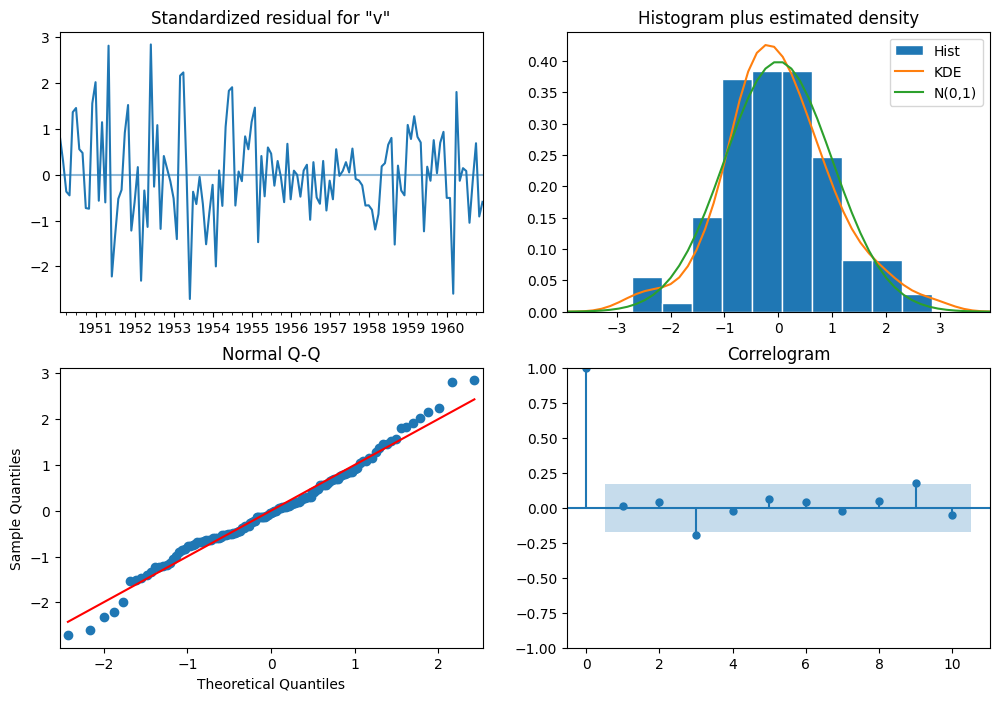

PRUEBA DE LJUNG-BOX Y DURBIN-WATSON
                       Test  Estadístico  P-valor                 Conclusión
0             Durbin-Watson       1.9675      NaN        Sin autocorrelación
1  Ljung-Box (hasta lag 20)      37.9000   0.0002  Autocorrelación detectada


In [54]:
# Verificar ruido blanco
# Diagnostico del modelo
def plot_diagnostics(modelo, n_lags=10):
    if not "statsmodels" in str(type(modelo)):
        raise TypeError("El objeto debe ser un modelo ajustado de statsmodels.")

    # Diagnóstico
    modelo.plot_diagnostics(figsize=(12,8))
    plt.show()

    # test_autocorrelacion
    test_autocorrelacion(modelo.resid, n_lags=n_lags)

# Ejecución de la función
plot_diagnostics(modelo = mejor_modelo, n_lags=20)

In [55]:
print('Buscando el mejor modelo SARIMA usando auto_arima...')
m_autoSARIMA = auto_arima(serie_log,                  # La serie transformada en logaritmo
                         start_p=0, start_q=0,
                         max_p=5, max_q=5,
                         d=None,                      # Permite a auto_arima encontrar el orden de diferenciación no estacional
                         seasonal=True,               # Habilitar búsqueda de componentes estacionales
                         m=12,                        # Período estacional (12 para datos mensuales)
                         start_P=0, start_Q=0,
                         max_P=3, max_Q=3,
                         D=None,                      # Permite a auto_arima encontrar el orden de diferenciación estacional
                         trace=True,                  # Mostrar progreso
                         error_action='ignore',       # Ignorar errores al ajustar algunos modelos
                         suppress_warnings=True,      # Suprimir advertencias
                         stepwise=True,               # Optimización por pasos (más rápida)
                         n_jobs=-1                    # Usar todos los núcleos disponibles
                        )

print('\nAuto-SARIMA - Resumen del modelo:')
print(m_autoSARIMA.summary())
print(f'Parámetros óptimos SARIMA: {m_autoSARIMA.order}{m_autoSARIMA.seasonal_order}')

# Guardar el modelo SARIMA óptimo
# Es importante ajustar el modelo final con statsmodels para que los objetos de resultado sean consistentes
# auto_arima devuelve una tupla para seasonal_order: (P, D, Q, s)
order = m_autoSARIMA.order
seasonal_order = m_autoSARIMA.seasonal_order

modelos["auto-SARIMA"] = ARIMA(serie_log, order=order, seasonal_order=seasonal_order, trend='n').fit()

Buscando el mejor modelo SARIMA usando auto_arima...
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=-358.005, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=-472.836, Time=0.94 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=-423.080, Time=0.67 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=-152.756, Time=0.04 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=-452.647, Time=0.17 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=-476.268, Time=2.25 sec
 ARIMA(1,0,0)(3,1,0)[12] intercept   : AIC=-477.914, Time=6.11 sec
 ARIMA(1,0,0)(3,1,1)[12] intercept   : AIC=-475.189, Time=6.01 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=-476.223, Time=2.54 sec
 ARIMA(0,0,0)(3,1,0)[12] intercept   : AIC=-381.464, Time=6.43 sec
 ARIMA(2,0,0)(3,1,0)[12] intercept   : AIC=-486.552, Time=8.28 sec
 ARIMA(2,0,0)(2,1,0)[12] intercept   : AIC=-484.436, Time=4.75 sec
 ARIMA(2,0,0)(3,1,1)[12] intercept   : AIC=-481.984, Time=5.53 sec
 ARIMA(2,0,0)(2,1,1)[12] intercep

In [56]:
# Comparar todos los modelos, incluyendo el nuevo SARIMA
df_comparacion, mejor_modelo_nombre = comparar_modelos_arima(modelos)

# Actualizar mejor_modelo con el nuevo mejor modelo si ha cambiado
mejor_modelo = modelos[mejor_modelo_nombre]

COMPARACIÓN DE MODELOS ARIMA
                 Modelo         AIC        AICc         BIC     Log-Lik       MSE      RMSE       MAE  Params  Obs
Ranking                                                                                                           
1           auto-SARIMA -478.512006 -477.898868 -461.215195  245.256003  1.951255  1.396873  0.429745       6  144
2        ARIMA(0, 1, 1) -447.990781 -447.801804 -439.365189  226.995390  0.001829  0.042770  0.032542       3  131
3            auto-ARIMA -447.990781 -447.801804 -439.365189  226.995390  0.001829  0.042770  0.032542       3  131
4        ARIMA(1, 1, 1) -446.265996 -445.948536 -434.765207  227.132998  0.001825  0.042722  0.032763       4  131
5        ARIMA(1, 1, 0) -376.685969 -376.592219 -370.950900  190.342985  0.003111  0.055772  0.041164       2  131
----------------------------------------------------------------------------------------------------
Mejor modelo (menor AICc): auto-SARIMA  →  AICc: -477.89886762933


Diagnósticos para el mejor modelo: auto-SARIMA


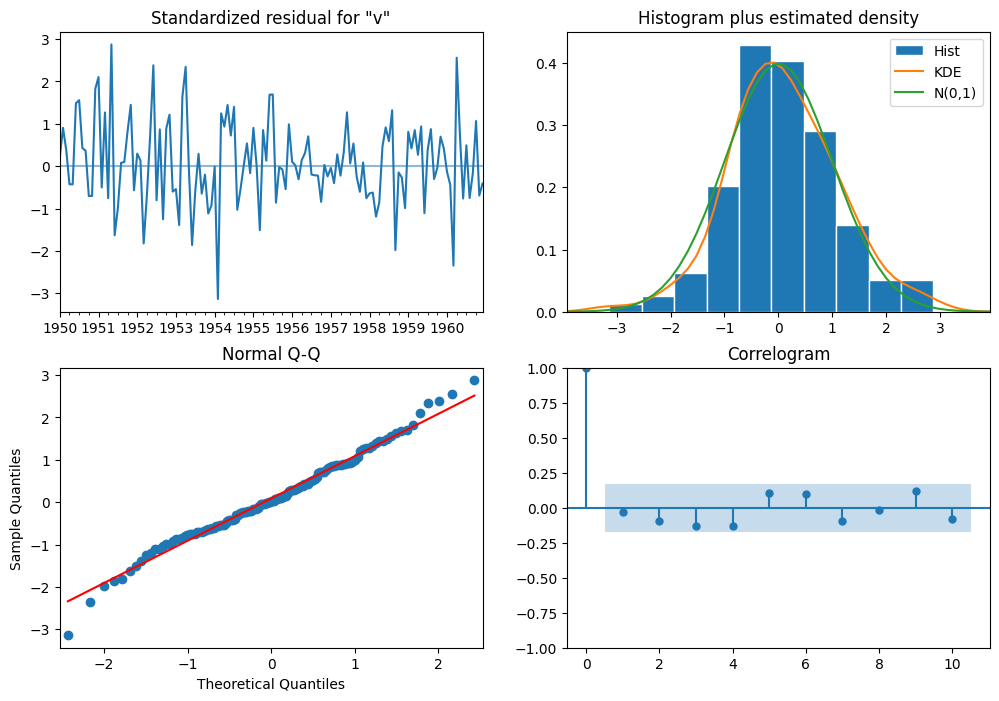

PRUEBA DE LJUNG-BOX Y DURBIN-WATSON
                       Test  Estadístico  P-valor                 Conclusión
0             Durbin-Watson       0.0818      NaN   Autocorrelación positiva
1  Ljung-Box (hasta lag 20)     521.6642      0.0  Autocorrelación detectada


In [57]:
# Realizar diagnósticos del nuevo mejor modelo
print(f"\nDiagnósticos para el mejor modelo: {mejor_modelo_nombre}")
plot_diagnostics(modelo = mejor_modelo, n_lags=20)